In [ ]:
!pip install datasets
!pip install --upgrade --quiet pip
!pip install --upgrade --quiet datasets[audio] transformers accelerate evaluate jiwer tensorboard gradio
!pip install --upgrade transformers

^C


ERROR: To modify pip, please run the following command:
C:\Users\erick\micromamba\envs\ml\python.exe -m pip install --upgrade --quiet pip


In [1]:
import os
import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm
from dataloader import Dataloader
from model_wrapper import WhisperWrapper, IntermediateLayerGetter
from model_evaluator import WhisperEvaluator
from feature_densities import build_feature_densities_estimation, eval_likelihood_all_audios

avail_dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
avail_dev = torch.device("xpu" if torch.xpu.is_available() else avail_dev)
print("Using device: ", avail_dev)

Using device:  xpu


In [2]:
def plot_uq(base_hist, base_buckets, target_ds, target_audios, model_wrap, evaluator, **kwargs):
    # Calculate UQ for target data
    uq_scores_test = eval_likelihood_all_audios(model_wrap, target_audios, base_hist, base_buckets, **kwargs)
    # Compute transcription
    transcriptions_list, gt_list = evaluator.transcribe_dataset(target_ds)
    # Fetch WERS
    wers = evaluator.compute_wers(transcriptions_list, gt_list)

    # Plot results
    wers_np = np.array(wers)
    uq_scores_fd_np = np.array(uq_scores_test)

    plt.scatter(uq_scores_fd_np, wers_np)
    plt.xlabel("UQ Score")
    plt.ylabel("WER")
    plt.show()

    pearson_corr = np.corrcoef(uq_scores_fd_np, wers_np)[0, 1]
    mean_wer = np.mean(wers_np)
    std_wer = np.std(wers_np)
    #print(f"Average WER: {mean_wer:.4f}\nStd WER: {std_wer:.4f}")
    #print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
    return mean_wer, std_wer, pearson_corr

In [3]:
#from google.colab import drive
#drive.mount('/content/drive')

#whisper_path = "/content/drive/My Drive/Whisper"
whisper_path = Path(r"C:\Users\erick\Models\Whisper")
print(os.listdir(whisper_path))

['processor_1', 'tokenizer_1', 'whisper_1']


In [4]:
# Create model
model_wrap = WhisperWrapper(model_path=whisper_path, device=avail_dev)
# Create evaluator
whisper_evaluator = WhisperEvaluator(model = model_wrap.model_cond_gen, processor = model_wrap.processor)

In [5]:
def get_layer_names(model, name = ""):
    children = model.named_children()
    if len(list(children)) > 0:
        layer_names = []
        for child_name, module in model.named_children():
            layer_names += get_layer_names(module, f"{name}.{child_name}")

        return layer_names
    
    else:
        return [name[1:]]

def print_children(name, module):
    print(f"Name: {name}")
    print(f"Module: {module}")
    for name, module in module.named_children():
        print_children(name, module)
    print(20*'=')

#print_children("Whisper", model_wrap.model)
layer_names = get_layer_names(model_wrap.model)
print(layer_names)


['encoder.conv1', 'encoder.conv2', 'encoder.embed_positions', 'encoder.layers.0.self_attn.k_proj', 'encoder.layers.0.self_attn.v_proj', 'encoder.layers.0.self_attn.q_proj', 'encoder.layers.0.self_attn.out_proj', 'encoder.layers.0.self_attn_layer_norm', 'encoder.layers.0.activation_fn', 'encoder.layers.0.fc1', 'encoder.layers.0.fc2', 'encoder.layers.0.final_layer_norm', 'encoder.layers.1.self_attn.k_proj', 'encoder.layers.1.self_attn.v_proj', 'encoder.layers.1.self_attn.q_proj', 'encoder.layers.1.self_attn.out_proj', 'encoder.layers.1.self_attn_layer_norm', 'encoder.layers.1.activation_fn', 'encoder.layers.1.fc1', 'encoder.layers.1.fc2', 'encoder.layers.1.final_layer_norm', 'encoder.layers.2.self_attn.k_proj', 'encoder.layers.2.self_attn.v_proj', 'encoder.layers.2.self_attn.q_proj', 'encoder.layers.2.self_attn.out_proj', 'encoder.layers.2.self_attn_layer_norm', 'encoder.layers.2.activation_fn', 'encoder.layers.2.fc1', 'encoder.layers.2.fc2', 'encoder.layers.2.final_layer_norm', 'encoder

In [6]:
# Load data
featured_df, featured_audios = Dataloader.load_dataset_raw_uq(partition_type = "fine_tuning_partition",
                                                              partition_id = "fine_tuning_partition")
#calibration_ds, calibration_audios = Dataloader.load_uq_partitions("calibration")
#finetune_ds, finetune_audios = Dataloader.load_uq_partitions("fine-tune")
test_ds, test_audios = Dataloader.load_uq_partitions("test", 1, 11)

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

...

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

In [7]:
x = test_audios[0][0]
hooked_model = IntermediateLayerGetter(model_wrap.model, 
                                       {"decoder.layers.0.final_layer_norm": "decoder.layers.0.final_layer_norm",
                                        "decoder.layers.1.final_layer_norm": "decoder.layers.1.final_layer_norm",
                                        "decoder.layers.2.final_layer_norm": "decoder.layers.2.final_layer_norm",
                                        "decoder.layers.3.final_layer_norm": "decoder.layers.3.final_layer_norm",},
                                        keep_output=False)

device = model_wrap.device
input_features = model_wrap.feature_extractor(x, return_tensors="pt", sampling_rate = model_wrap.sampling_rate).input_features.to(device)
decoder_input_ids = torch.tensor([[1, 1]], device=device) * model_wrap.model.config.decoder_start_token_id
interm = hooked_model(input_features, decoder_input_ids = decoder_input_ids)
#print(interm)
"""device = model_wrap.device
# Encode the inputs
input_features = model_wrap.feature_extractor(x, return_tensors="pt", sampling_rate = model_wrap.sampling_rate).input_features.to(device)
decoder_input_ids = torch.tensor([[1, 1]], device=device) * model_wrap.model.config.decoder_start_token_id
# Extract the vector embedding
embedding = model_wrap.model(input_features, decoder_input_ids = decoder_input_ids).last_hidden_state
# Last_hidden_state returns a sequence of hidden states
selected_embedding = embedding[0, 0, :].cpu().detach()"""
    

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.43.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


'device = model_wrap.device\n# Encode the inputs\ninput_features = model_wrap.feature_extractor(x, return_tensors="pt", sampling_rate = model_wrap.sampling_rate).input_features.to(device)\ndecoder_input_ids = torch.tensor([[1, 1]], device=device) * model_wrap.model.config.decoder_start_token_id\n# Extract the vector embedding\nembedding = model_wrap.model(input_features, decoder_input_ids = decoder_input_ids).last_hidden_state\n# Last_hidden_state returns a sequence of hidden states\nselected_embedding = embedding[0, 0, :].cpu().detach()'

In [8]:
def execute_experiment(model_wrap, featured_audios, exp_name, **kwargs):

    # Use FD training data to estimate feature densities
    histograms_all_features, buckets_all_features = build_feature_densities_estimation(model_wrap, featured_audios, **kwargs)

    # Collect data for each partition
    mean_wers = []
    std_wers = []
    pearson_corrs = []
    partitions = list(range(9))
    for i in tqdm(partitions, desc = "Processing partitions", leave=False):
        mean_wer, std_wer, pearson_corr = plot_uq(histograms_all_features, buckets_all_features, test_ds[i], test_audios[i], model_wrap, whisper_evaluator, **kwargs)
        mean_wers.append(mean_wer)
        std_wers.append(std_wer)
        pearson_corrs.append(pearson_corr)
        print(f"Partition {i} - Mean WER: {mean_wer:.4f}, Std WER: {std_wer:.4f}, Pearson correlation coefficient: {pearson_corr:.4f}")

    # Print results
    res = pd.DataFrame({"Partition": partitions, "R": pearson_corrs, "Mean WER": mean_wers, "Std WER": std_wers})
    print("=============== Results ===============\n", res)
    print("=============== Mean results ===============\n", res.mean())
    res.to_csv(f"{exp_name}.csv", index = False)

Extracting embeddings:   0%|          | 0/1999 [00:00<?, ?it/s]

Processing partitions:   0%|          | 0/9 [00:00<?, ?it/s]

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

You have passed task=transcribe, but also have set `forced_decoder_ids` to [(1, 50262), (2, 50359), (3, 50363)] which creates a conflict. `forced_decoder_ids` will be ignored in favor of task=transcribe.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
c:\Users\erick\micromamba\envs\ml\lib\site-packages\transformers\pytorch_utils.py:335: UserWarning: Aten Op fallback from XPU to CPU happends. This may have performance implications. If need debug the fallback ops please set environment variable `PYTORCH_DEBUG_XPU_FALLBACK=1`  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen\xpu\RegisterXPU.cpp:7617.)
  return torch.isin(elements, test_elements)


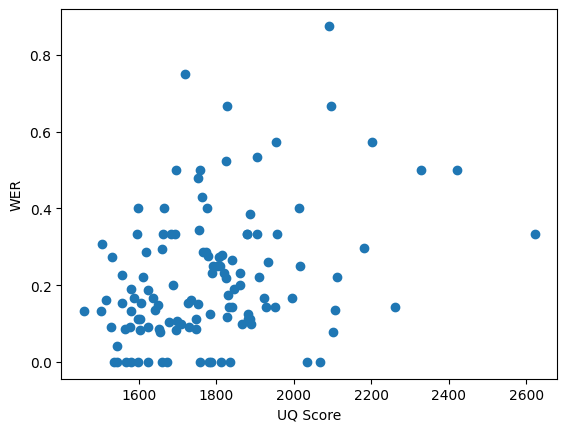

Partition 0 - Mean WER: 0.2190, Std WER: 0.1717, Pearson correlation coefficient: 0.3451


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

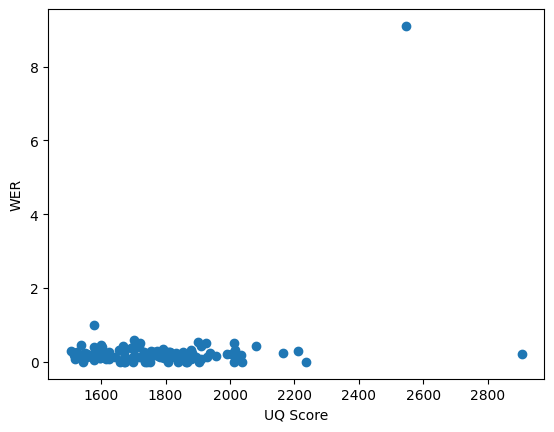

Partition 1 - Mean WER: 0.2813, Std WER: 0.8231, Pearson correlation coefficient: 0.3335


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

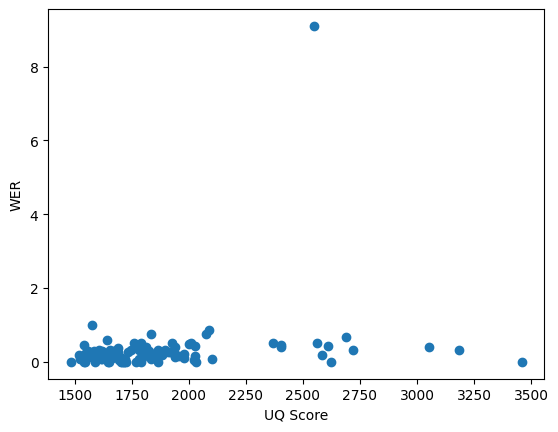

Partition 2 - Mean WER: 0.3054, Std WER: 0.8284, Pearson correlation coefficient: 0.2329


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

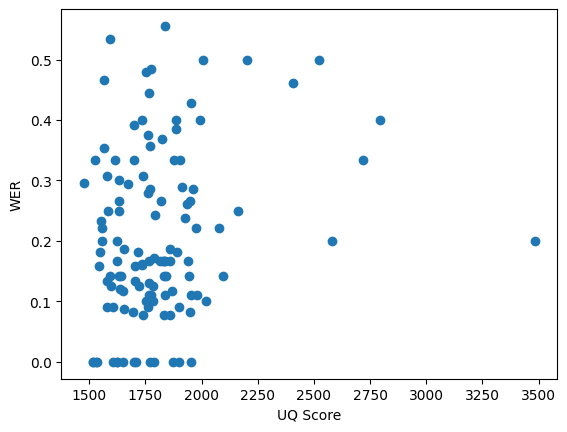

Partition 3 - Mean WER: 0.2060, Std WER: 0.1403, Pearson correlation coefficient: 0.2337


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

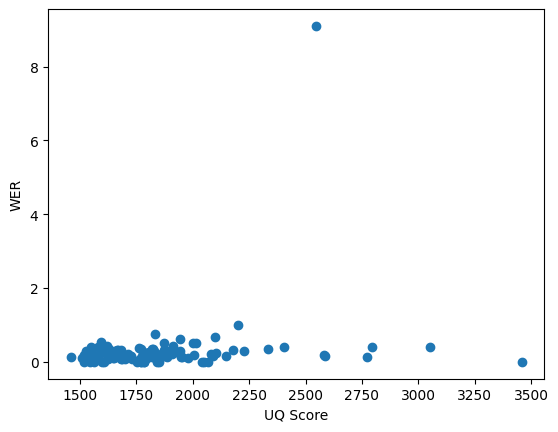

Partition 4 - Mean WER: 0.2912, Std WER: 0.8247, Pearson correlation coefficient: 0.2326


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

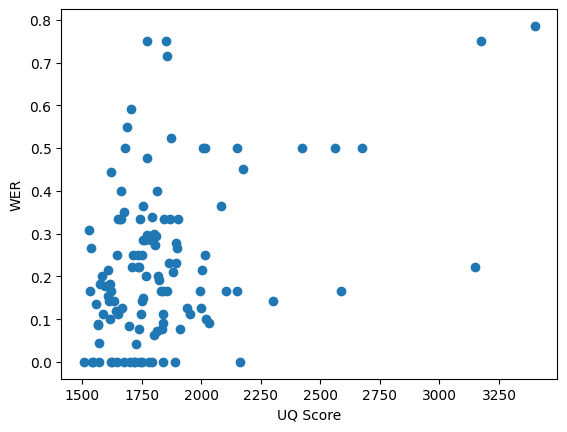

Partition 5 - Mean WER: 0.2267, Std WER: 0.1841, Pearson correlation coefficient: 0.4105


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

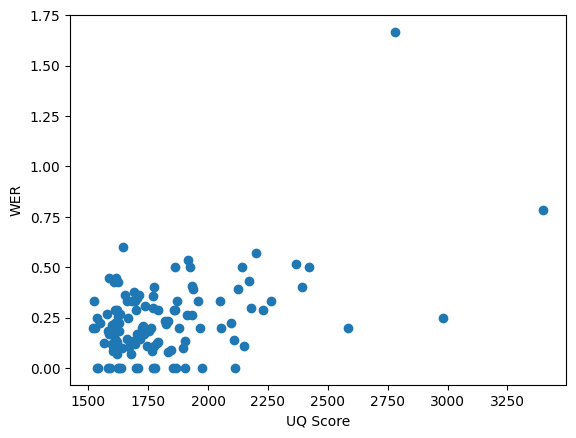

Partition 6 - Mean WER: 0.2377, Std WER: 0.2023, Pearson correlation coefficient: 0.4864


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

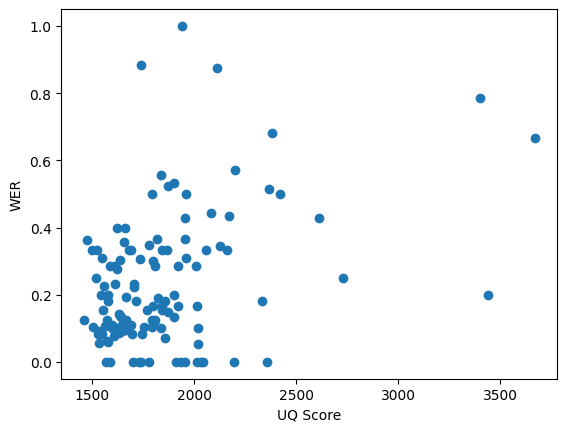

Partition 7 - Mean WER: 0.2334, Std WER: 0.1984, Pearson correlation coefficient: 0.3804


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

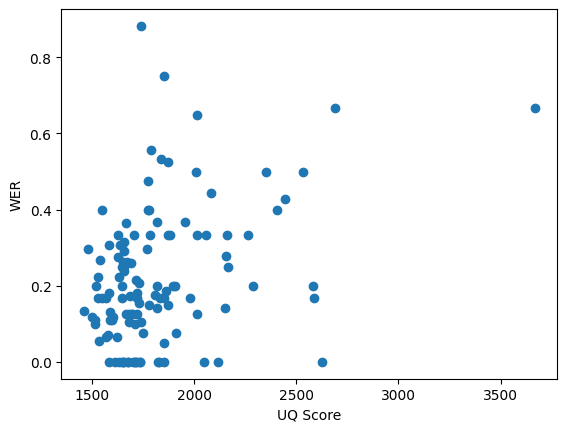

Partition 8 - Mean WER: 0.2171, Std WER: 0.1766, Pearson correlation coefficient: 0.3754
=============== Results ===============
    Partition         R  Mean WER   Std WER
0          0  0.345124  0.218966  0.171679
1          1  0.333525  0.281326  0.823102
2          2  0.232870  0.305386  0.828395
3          3  0.233663  0.205980  0.140332
4          4  0.232615  0.291216  0.824666
5          5  0.410492  0.226660  0.184113
6          6  0.486448  0.237704  0.202348
7          7  0.380439  0.233382  0.198414
8          8  0.375400  0.217066  0.176632
=============== Mean results ===============
 Partition    4.000000
R            0.336731
Mean WER     0.246409
Std WER      0.394409
dtype: float64


In [9]:
execute_experiment(model_wrap, featured_audios, "baseline-last_hidden_state")

Extracting embeddings:   0%|          | 0/1999 [00:00<?, ?it/s]

Processing partitions:   0%|          | 0/9 [00:00<?, ?it/s]

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

You have passed task=transcribe, but also have set `forced_decoder_ids` to [(1, 50262), (2, 50359), (3, 50363)] which creates a conflict. `forced_decoder_ids` will be ignored in favor of task=transcribe.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
c:\Users\erick\micromamba\envs\ml\lib\site-packages\transformers\pytorch_utils.py:335: UserWarning: Aten Op fallback from XPU to CPU happends. This may have performance implications. If need debug the fallback ops please set environment variable `PYTORCH_DEBUG_XPU_FALLBACK=1`  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen\xpu\RegisterXPU.cpp:7617.)
  return torch.isin(elements, test_elements)


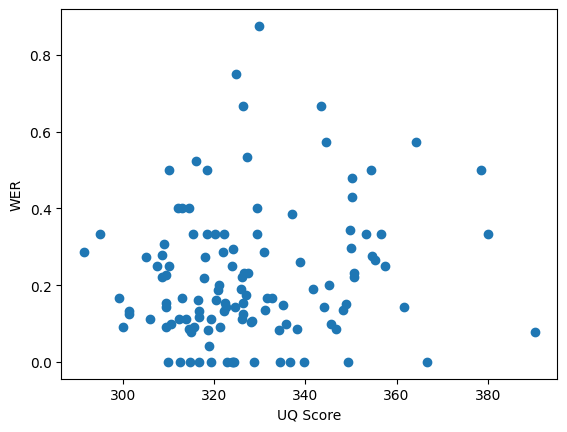

Partition 0 - Mean WER: 0.2190, Std WER: 0.1717, Pearson correlation coefficient: 0.1485


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

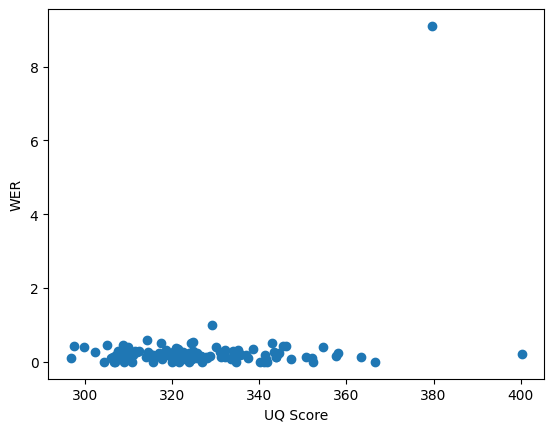

Partition 1 - Mean WER: 0.2813, Std WER: 0.8231, Pearson correlation coefficient: 0.2794


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

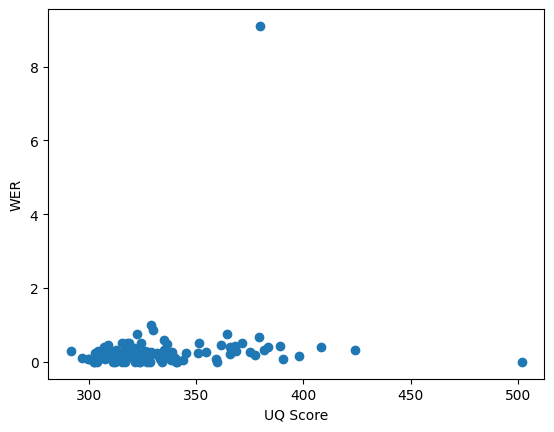

Partition 2 - Mean WER: 0.3054, Std WER: 0.8284, Pearson correlation coefficient: 0.1741


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

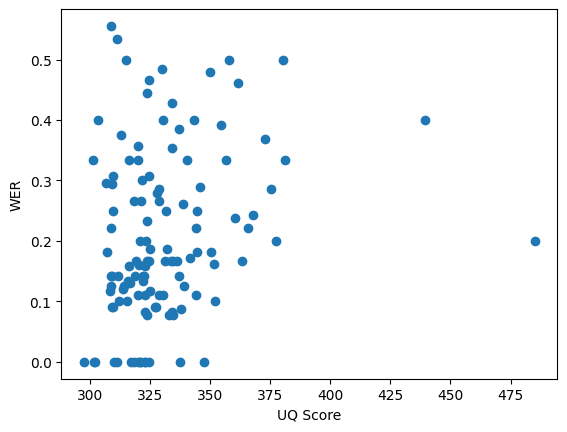

Partition 3 - Mean WER: 0.2060, Std WER: 0.1403, Pearson correlation coefficient: 0.2398


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

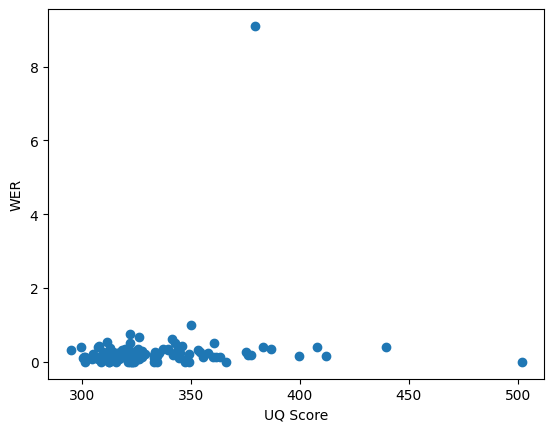

Partition 4 - Mean WER: 0.2912, Std WER: 0.8247, Pearson correlation coefficient: 0.1579


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

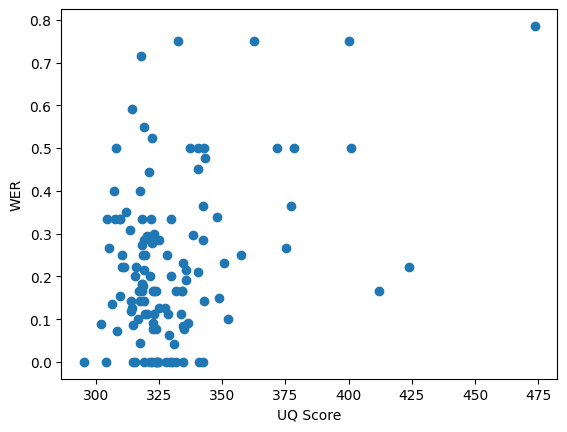

Partition 5 - Mean WER: 0.2267, Std WER: 0.1841, Pearson correlation coefficient: 0.3671


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

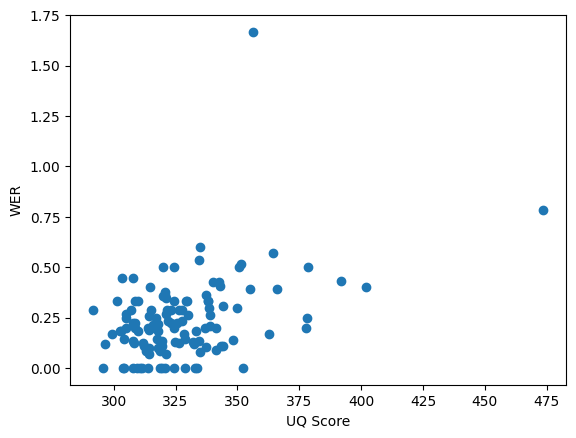

Partition 6 - Mean WER: 0.2377, Std WER: 0.2023, Pearson correlation coefficient: 0.4154


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

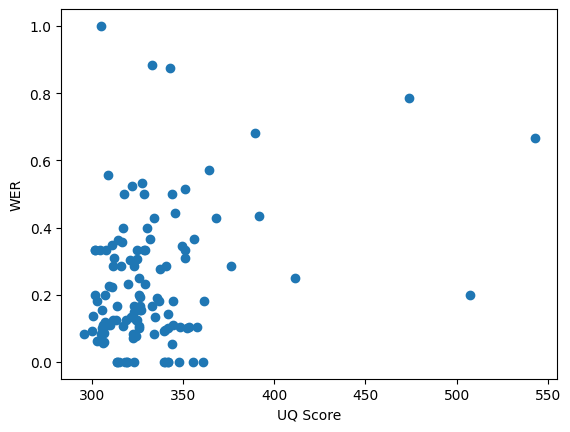

Partition 7 - Mean WER: 0.2334, Std WER: 0.1984, Pearson correlation coefficient: 0.2884


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

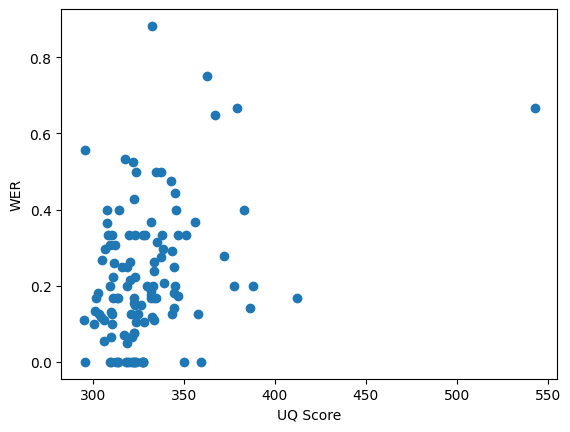

Partition 8 - Mean WER: 0.2171, Std WER: 0.1766, Pearson correlation coefficient: 0.3406
=============== Results ===============
    Partition         R  Mean WER   Std WER
0          0  0.148471  0.218966  0.171679
1          1  0.279369  0.281326  0.823102
2          2  0.174147  0.305386  0.828395
3          3  0.239761  0.205980  0.140332
4          4  0.157864  0.291216  0.824666
5          5  0.367107  0.226660  0.184113
6          6  0.415434  0.237704  0.202348
7          7  0.288359  0.233382  0.198414
8          8  0.340584  0.217066  0.176632
=============== Mean results ===============
 Partition    4.000000
R            0.267900
Mean WER     0.246409
Std WER      0.394409
dtype: float64


In [9]:
execute_experiment(model_wrap, featured_audios, "quantile-75", embedding_filter="quantile")

Extracting embeddings:   0%|          | 0/1999 [00:00<?, ?it/s]

Processing partitions:   0%|          | 0/9 [00:00<?, ?it/s]

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

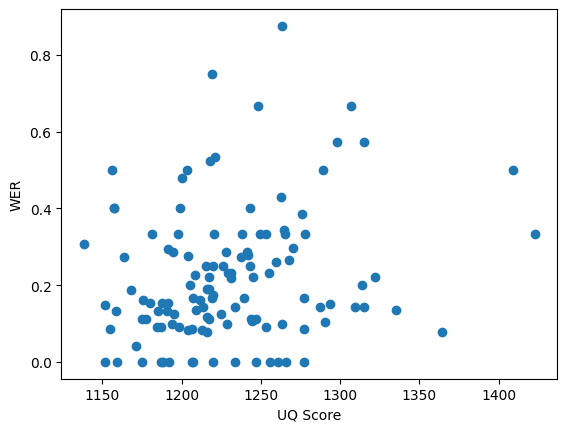

Partition 0 - Mean WER: 0.2190, Std WER: 0.1717, Pearson correlation coefficient: 0.2146


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

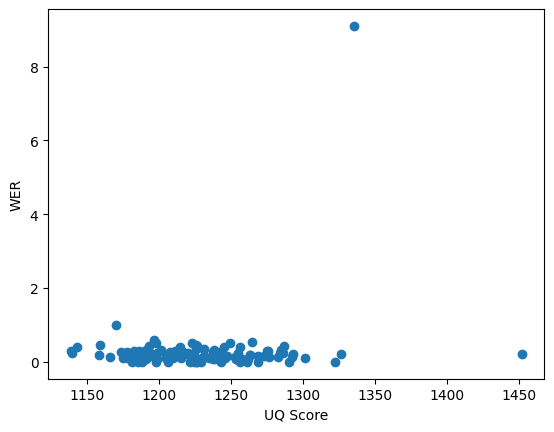

Partition 1 - Mean WER: 0.2813, Std WER: 0.8231, Pearson correlation coefficient: 0.1962


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

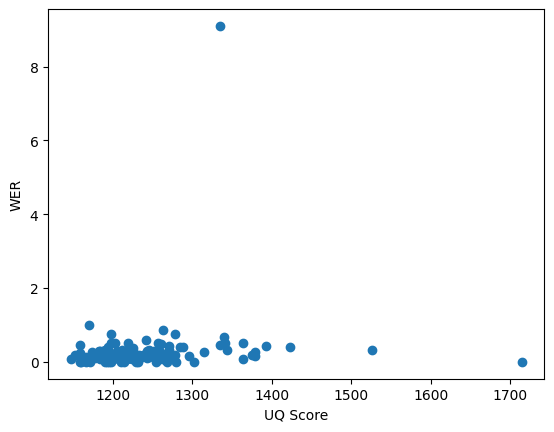

Partition 2 - Mean WER: 0.3054, Std WER: 0.8284, Pearson correlation coefficient: 0.1353


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

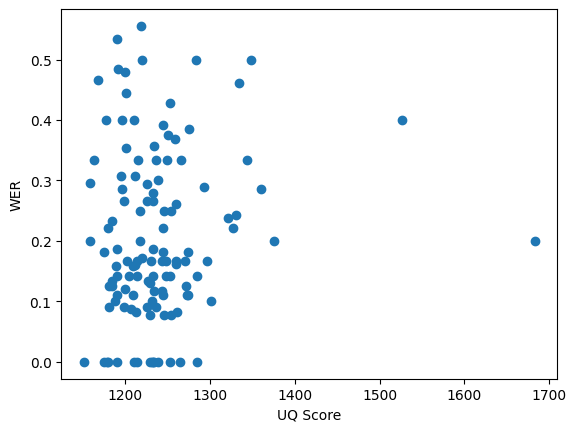

Partition 3 - Mean WER: 0.2060, Std WER: 0.1403, Pearson correlation coefficient: 0.1196


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

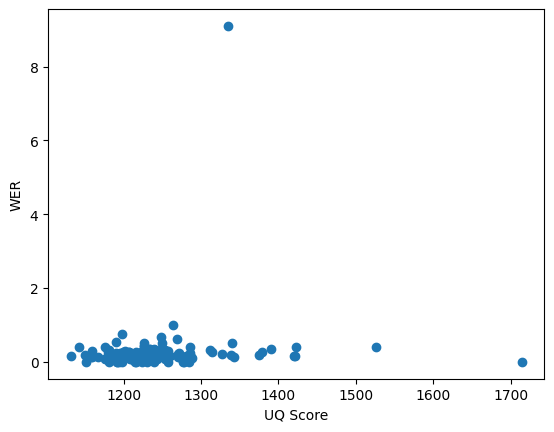

Partition 4 - Mean WER: 0.2912, Std WER: 0.8247, Pearson correlation coefficient: 0.1235


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

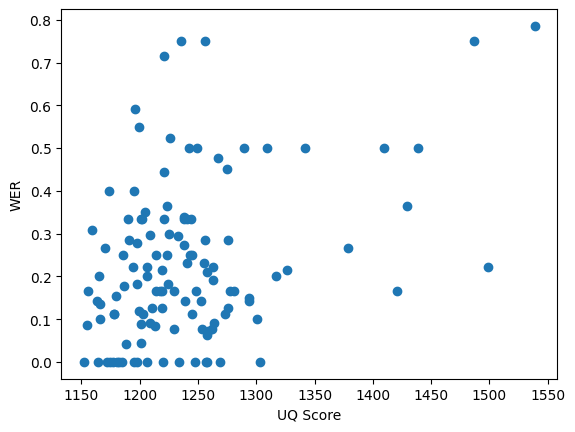

Partition 5 - Mean WER: 0.2267, Std WER: 0.1841, Pearson correlation coefficient: 0.3801


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

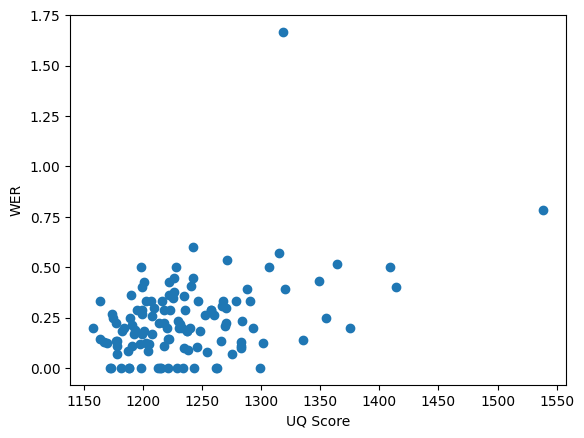

Partition 6 - Mean WER: 0.2377, Std WER: 0.2023, Pearson correlation coefficient: 0.4042


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

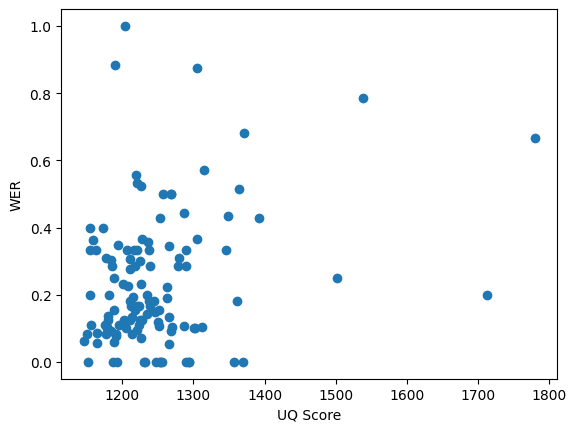

Partition 7 - Mean WER: 0.2334, Std WER: 0.1984, Pearson correlation coefficient: 0.2670


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

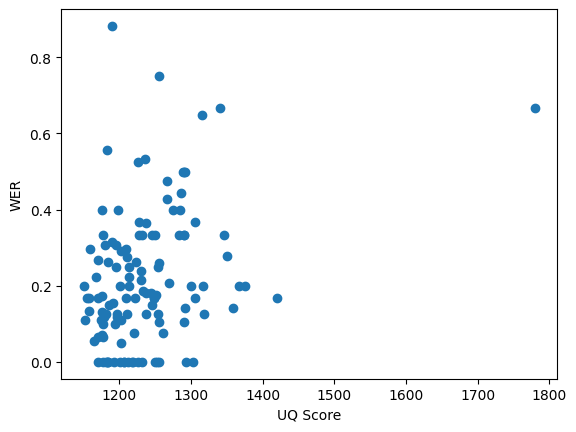

Partition 8 - Mean WER: 0.2171, Std WER: 0.1766, Pearson correlation coefficient: 0.3335
=============== Results ===============
    Partition         R  Mean WER   Std WER
0          0  0.214574  0.218966  0.171679
1          1  0.196234  0.281326  0.823102
2          2  0.135316  0.305386  0.828395
3          3  0.119558  0.205980  0.140332
4          4  0.123475  0.291216  0.824666
5          5  0.380084  0.226660  0.184113
6          6  0.404230  0.237704  0.202348
7          7  0.266968  0.233382  0.198414
8          8  0.333515  0.217066  0.176632
=============== Mean results ===============
 Partition    4.000000
R            0.241551
Mean WER     0.246409
Std WER      0.394409
dtype: float64


In [10]:
execute_experiment(model_wrap, featured_audios, "quantile-25", embedding_filter="quantile", custom_filter_fn = lambda: 0.25)